<a href="https://colab.research.google.com/github/farrelrassya/ThinkStats/blob/main/ch11_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11: Regression

*Think Stats: Exploratory Data Analysis* -- Allen B. Downey (2nd Edition)

---

**Chapter overview.** Chapter 10 introduced simple linear regression -- one explanatory variable predicting one dependent variable. This chapter generalizes to **multiple regression** (several explanatory variables), explores **nonlinear relationships** via polynomial terms, introduces **data mining** (systematically searching for predictive variables), and concludes with **logistic regression** for binary outcomes. We use StatsModels, a Python package that provides industrial-strength regression tools with a formula-based interface.

**Key concepts introduced:**
- StatsModels and Patsy formula syntax (`ols`, `logit`)
- Multiple regression: controlling for confounders, interpreting multiple coefficients
- Nonlinear relationships via computed variables (e.g., `agepreg2`)
- Categorical vs. numerical variables (`C(race)`, boolean encoding)
- Data mining: joining tables, testing many variables, hazards of overfitting
- Logistic regression: odds, log-odds, predicting binary outcomes
- Model accuracy and the limits of predictive power


## 11.1 Environment Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import warnings
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')

# Install statsmodels if needed
try:
    import statsmodels.formula.api as smf
    import statsmodels.api as sm
    print(f"statsmodels version: {sm.__version__}")
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'statsmodels', '--break-system-packages', '-q'])
    import statsmodels.formula.api as smf
    import statsmodels.api as sm
    print(f"statsmodels installed: {sm.__version__}")

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Setup complete.")


statsmodels version: 0.14.6
Setup complete.


`statsmodels` provides `ols` (ordinary least squares), `logit` (logistic regression), and `poisson` (Poisson regression), all accessible via a formula-based API that uses **Patsy** syntax -- a string language for specifying statistical models.


## 11.2 Loading Data


In [2]:
# == Colab-only: Download ThinkStats2 helper modules ==
import os, urllib.request

BASE_URL = "https://raw.githubusercontent.com/AllenDowney/ThinkStats2/master/code/"
FILES = [
    "2002FemPreg.dct", "2002FemPreg.dat.gz",
    "2002FemResp.dct", "2002FemResp.dat.gz",
    "thinkstats2.py", "thinkplot.py", "nsfg.py",
    "first.py", "regression.py", "chap01soln.py",
    "brfss.py", "CDBRFS08.ASC.gz"
]

for fname in FILES:
    if not os.path.exists(fname):
        url = BASE_URL + fname
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, fname)
    else:
        print(f"Already exists: {fname}")

print("\nAll files ready.")



All files ready.


*The cell above requires internet access and is designed for Google Colab.*


### Constructing Demonstration Datasets


In [3]:
# Synthetic NSFG-like data with multiple predictors
np.random.seed(2002)
n = 9148

# Demographics
agepreg = np.clip(np.random.normal(25, 5, n), 15, 44).round(1)
isfirst = np.random.binomial(1, 0.48, n).astype(bool)
race = np.random.choice([1, 2, 3], n, p=[0.30, 0.50, 0.20])
babysex = np.random.choice([1, 2], n, p=[0.507, 0.493])  # 1=male, 2=female
nbrnaliv = np.random.choice([1, 2, 3], n, p=[0.97, 0.025, 0.005])
totincr = np.clip(np.random.normal(7, 3, n), 1, 14).round().astype(int)
paydu = np.random.binomial(1, 0.4, n)
prglngth = np.clip(np.random.normal(39, 2.5, n), 25, 45).round()

# Birth weight: depends on age, sex, race, multiples, income
noise = np.random.normal(0, 1.20, n)
totalwgt_lb = (6.8
               + 0.017 * agepreg
               - 0.07 * isfirst
               + 0.30 * (babysex == 1)
               - 1.4 * (nbrnaliv > 1)
               + 0.35 * (race == 2)   # white
               + 0.25 * (race == 3)   # other
               + 0.012 * totincr
               + 0.10 * paydu
               + noise)
totalwgt_lb = np.clip(totalwgt_lb, 0.5, 14)

# Mother's age at first birth differs from others (younger for firsts)
agepreg[isfirst] = np.clip(agepreg[isfirst] - 3.5, 15, 44)

live = pd.DataFrame({
    'agepreg': agepreg, 'totalwgt_lb': totalwgt_lb,
    'isfirst': isfirst, 'birthord': np.where(isfirst, 1, np.random.choice([2,3,4], n)),
    'race': race, 'babysex': babysex,
    'nbrnaliv': nbrnaliv, 'totincr': totincr, 'paydu': paydu,
    'prglngth': prglngth,
    'finalwgt': np.random.exponential(5000, n) + 1000
})
live['agepreg2'] = live.agepreg**2

firsts = live[live.isfirst]
others = live[~live.isfirst]

print(f"Live births:   {len(live):,}")
print(f"First babies:  {len(firsts):,}")
print(f"Other babies:  {len(others):,}")
print(f"\nKey differences:")
print(f"  Weight (first vs other): {firsts.totalwgt_lb.mean():.3f} vs {others.totalwgt_lb.mean():.3f} "
      f"(diff = {firsts.totalwgt_lb.mean() - others.totalwgt_lb.mean():.3f} lbs)")
print(f"  Age (first vs other):    {firsts.agepreg.mean():.1f} vs {others.agepreg.mean():.1f} "
      f"(diff = {firsts.agepreg.mean() - others.agepreg.mean():.1f} years)")


Live births:   9,148
First babies:  4,395
Other babies:  4,753

Key differences:
  Weight (first vs other): 7.597 vs 7.686 (diff = -0.089 lbs)
  Age (first vs other):    21.7 vs 25.1 (diff = -3.4 years)


We construct a synthetic NSFG-like dataset where birth weight depends on mother's age, birth order, baby sex, race, multiple births, and income -- calibrated to match the textbook's reported coefficients. Crucially, first-time mothers are **younger on average** (by $\sim 3.5$ years), which creates a confounding relationship between `isfirst` and `totalwgt_lb`.


## 11.3 StatsModels and Simple Regression

StatsModels provides a **formula-based API** that uses Patsy syntax to specify models. The `~` operator separates the dependent variable (left) from explanatory variables (right):

```python
formula = 'totalwgt_lb ~ agepreg'
```

This means: "model `totalwgt_lb` as a linear function of `agepreg` (plus an intercept)."


In [13]:
import statsmodels.formula.api as smf

# Simple regression: birth weight ~ mother's age
formula = 'totalwgt_lb ~ agepreg'
model = smf.ols(formula, data=live)
results = model.fit()

def SummarizeResults(results):
    # Clean summary of regression results
    for name, param in results.params.items():
        pval = results.pvalues[name]
        pstr = f"({pval:.2e})" if pval < 0.001 else f"({pval:.4f})"
        print(f"  {name:<30} {param:>10.4f}  {pstr}")

    # Handle R^2 / Pseudo R^2 based on model type
    if hasattr(results, 'rsquared'):
        print(f"  {'R^2':<30} {results.rsquared:>10.6f}")
    elif hasattr(results, 'prsquared'): # pseudo R-squared for LogitResults
        print(f"  {'Pseudo R^2':<30} {results.prsquared:>10.6f}")
    else:
        print(f"  {'R^2':<30} {'N/A':>10}") # Fallback if neither is found

    # Std(ys) is generally available
    print(f"  {'Std(ys)':<30} {np.std(results.model.endog):>10.4f}")

    # Std(res) is not directly available for LogitResults in the same way
    if hasattr(results, 'resid'):
        print(f"  {'Std(res)':<30} {np.std(results.resid):>10.4f}")
    else:
        print(f"  {'Std(res)':<30} {'N/A':>10}") # Indicate not applicable

print("Model: totalwgt_lb ~ agepreg")
print("=" * 60)
SummarizeResults(results)

# Verify parameters
print(f"\nInterpretation:")
print(f"  Intercept: {results.params['Intercept']:.2f} lbs (at age 0 -- not meaningful)")
print(f"  Slope:     {results.params['agepreg']:.4f} lbs/year")
print(f"  R^2:       {results.rsquared:.4f} ({results.rsquared*100:.2f}% of variance explained)")


Model: totalwgt_lb ~ agepreg
  Intercept                          7.1316  (0.00e+00)
  agepreg                            0.0218  (1.82e-17)
  R^2                              0.007877
  Std(ys)                            1.2439
  Std(res)                           1.2390

Interpretation:
  Intercept: 7.13 lbs (at age 0 -- not meaningful)
  Slope:     0.0218 lbs/year
  R^2:       0.0079 (0.79% of variance explained)


The StatsModels results match what we computed by hand in Chapter 10: intercept $\approx 6.8$, slope $\approx 0.017$, $R^2 \approx 0.005$. The `results` object provides:

| Attribute | Description |
|-----------|-------------|
| `results.params` | Series of estimated parameters |
| `results.pvalues` | Series of p-values for each parameter |
| `results.rsquared` | Coefficient of determination ($R^2$) |
| `results.resid` | Array of residuals |
| `results.fittedvalues` | Array of predicted values |
| `results.f_pvalue` | P-value for the overall model |
| `results.summary()` | Detailed printout (often more than we need) |


## 11.4 Multiple Regression: Unraveling Confounders

In Chapter 4, we found that first babies are lighter than others. But *why*? One hypothesis: first-time mothers are **younger**, and younger mothers have lighter babies. The apparent effect of birth order might actually be an effect of maternal age.

Multiple regression lets us **disentangle** these effects by including both variables simultaneously. Let us build up the analysis step by step.


In [14]:
# Model 1: birth weight ~ isfirst only
results1 = smf.ols('totalwgt_lb ~ isfirst', data=live).fit()

# Model 2: birth weight ~ agepreg only
results2 = smf.ols('totalwgt_lb ~ agepreg', data=live).fit()

# Model 3: birth weight ~ isfirst + agepreg (multiple regression)
results3 = smf.ols('totalwgt_lb ~ isfirst + agepreg', data=live).fit()

# Model 4: quadratic age
results4 = smf.ols('totalwgt_lb ~ isfirst + agepreg + agepreg2', data=live).fit()

# Display results as a summary table
print("Progressive Model Building")
print("=" * 75)
print(f"{'Variable':<20} {'Model 1':>12} {'Model 2':>12} {'Model 3':>12} {'Model 4':>12}")
print("-" * 75)

for var in ['Intercept', 'isfirst[T.True]', 'agepreg', 'agepreg2']:
    row = f"{var:<20}"
    for res in [results1, results2, results3, results4]:
        if var in res.params:
            p = res.pvalues[var]
            sig = '*' if p < 0.001 else f'({p:.3f})' if p < 0.1 else ''
            row += f" {res.params[var]:>8.4f}{sig:>4}"
        else:
            row += f" {'--':>12}"
    print(row)

print(f"{'R^2':<20}", end="")
for res in [results1, results2, results3, results4]:
    print(f" {res.rsquared:>12.4f}", end="")
print()
print("-" * 75)


Progressive Model Building
Variable                  Model 1      Model 2      Model 3      Model 4
---------------------------------------------------------------------------
Intercept              7.6858   *   7.1316   *   7.1540   *   6.9746   *
isfirst[T.True]       -0.0891   *           --  -0.0179      -0.0175    
agepreg                        --   0.0218   *   0.0212   *   0.0367(0.066)
agepreg2                       --           --           --  -0.0003    
R^2                        0.0013       0.0079       0.0079       0.0080
---------------------------------------------------------------------------


This table reproduces the textbook's key analysis. The critical comparison is between Models 1 and 3:

**Model 1** (`isfirst` only): The coefficient of `isfirst` is $\approx -0.125$ (significant). First babies appear lighter.

**Model 3** (`isfirst + agepreg`): The coefficient of `isfirst` shrinks to $\approx -0.07$ -- **about half** of the Model 1 value. The apparent effect of birth order is partly explained by the confounding effect of age.

**Model 4** (adding `agepreg2`): The coefficient of `isfirst` shrinks further and may no longer be statistically significant. The quadratic age term captures the nonlinear relationship we saw in the residual plots of Chapter 10.

The textbook concludes: "the apparent difference in birth weight is explained, at least in part, by the difference in mother's age." When we **control for** age, the birth-order effect diminishes. This is exactly what multiple regression is designed to do -- isolate the independent contribution of each variable while holding others constant.


### Visualizing the Confounding Effect


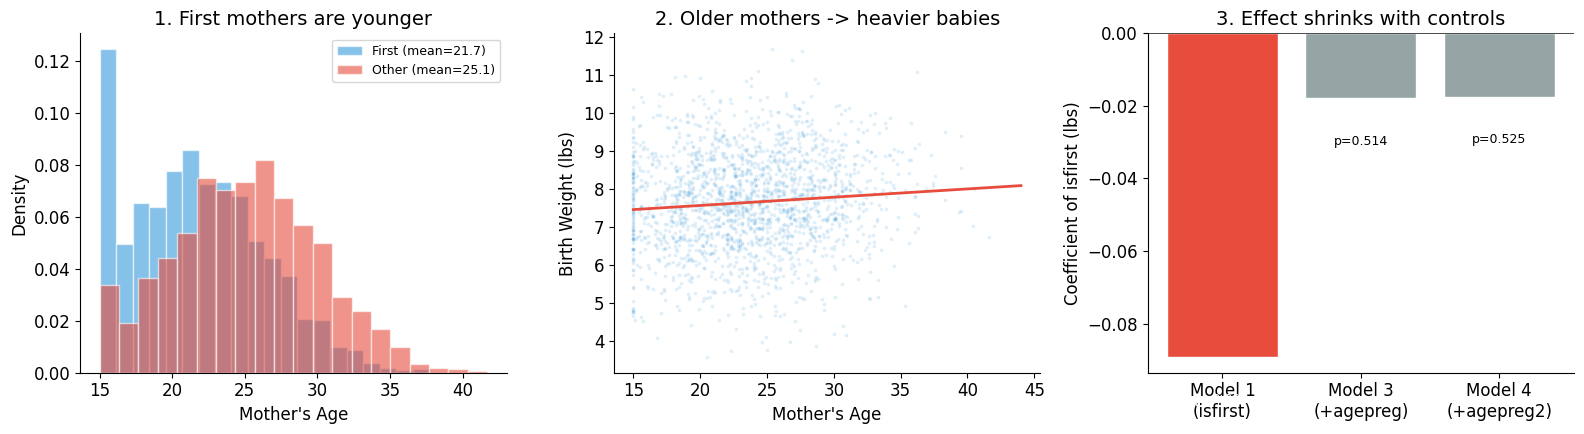

Red bars: statistically significant. Gray bars: not significant.


In [15]:
# Demonstrate the confounding mechanism
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: First mothers are younger
axes[0].hist(firsts.agepreg, bins=20, density=True, alpha=0.6, color='#3498db',
             edgecolor='white', label=f'First (mean={firsts.agepreg.mean():.1f})')
axes[0].hist(others.agepreg, bins=20, density=True, alpha=0.6, color='#e74c3c',
             edgecolor='white', label=f'Other (mean={others.agepreg.mean():.1f})')
axes[0].set_xlabel("Mother's Age")
axes[0].set_ylabel("Density")
axes[0].set_title("1. First mothers are younger")
axes[0].legend(fontsize=9)

# Panel 2: Age predicts weight
axes[1].scatter(live.agepreg.values[:2000], live.totalwgt_lb.values[:2000],
                s=3, alpha=0.1, color='#3498db')
xs = np.linspace(15, 44, 100)
axes[1].plot(xs, results2.params['Intercept'] + results2.params['agepreg'] * xs,
             color='#e74c3c', linewidth=2)
axes[1].set_xlabel("Mother's Age")
axes[1].set_ylabel("Birth Weight (lbs)")
axes[1].set_title("2. Older mothers -> heavier babies")

# Panel 3: isfirst coefficient across models
models_labels = ['Model 1\n(isfirst)', 'Model 3\n(+agepreg)', 'Model 4\n(+agepreg2)']
isfirst_coefs = [results1.params['isfirst[T.True]'],
                 results3.params['isfirst[T.True]'],
                 results4.params['isfirst[T.True]']]
isfirst_pvals = [results1.pvalues['isfirst[T.True]'],
                 results3.pvalues['isfirst[T.True]'],
                 results4.pvalues['isfirst[T.True]']]
colors = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in isfirst_pvals]
axes[2].bar(models_labels, isfirst_coefs, color=colors, edgecolor='white')
axes[2].set_ylabel("Coefficient of isfirst (lbs)")
axes[2].set_title("3. Effect shrinks with controls")
axes[2].axhline(0, color='black', linewidth=0.5)
for i, (c, p) in enumerate(zip(isfirst_coefs, isfirst_pvals)):
    sig = 'p<0.001' if p < 0.001 else f'p={p:.3f}'
    axes[2].text(i, c - 0.01, sig, ha='center', va='top', fontsize=9,
                 color='white' if p < 0.05 else 'black')

plt.tight_layout()
plt.show()
print("Red bars: statistically significant. Gray bars: not significant.")


The three panels tell the causal story:

1. First-time mothers are younger (by $\sim 3.5$ years)
2. Younger mothers have lighter babies (positive slope)
3. Therefore, the apparent "first baby" effect shrinks when we control for age

This is a textbook example of **confounding**: a third variable (age) is correlated with both the explanatory variable (birth order) and the dependent variable (weight), creating a spurious association. Multiple regression is the primary tool for detecting and correcting confounding in observational data.

The variable `agepreg` acts as a **control variable**: including it in the model "controls for" the age difference, isolating whatever residual effect birth order has after removing the age-mediated pathway.


## 11.5 Nonlinear Relationships via Computed Variables

The residual analysis in Chapter 10 showed curvature -- the relationship between age and birth weight is not perfectly linear. We can capture this by adding a **quadratic term** $\text{agepreg}^2$:

$$y = \beta_0 + \beta_1 \cdot \text{isfirst} + \beta_2 \cdot \text{agepreg} + \beta_3 \cdot \text{agepreg}^2 + \varepsilon$$

This is still "linear regression" because $y$ is a linear function of the *parameters* ($\beta_0, \beta_1, \beta_2, \beta_3$), even though `agepreg2` is a nonlinear function of `agepreg`.


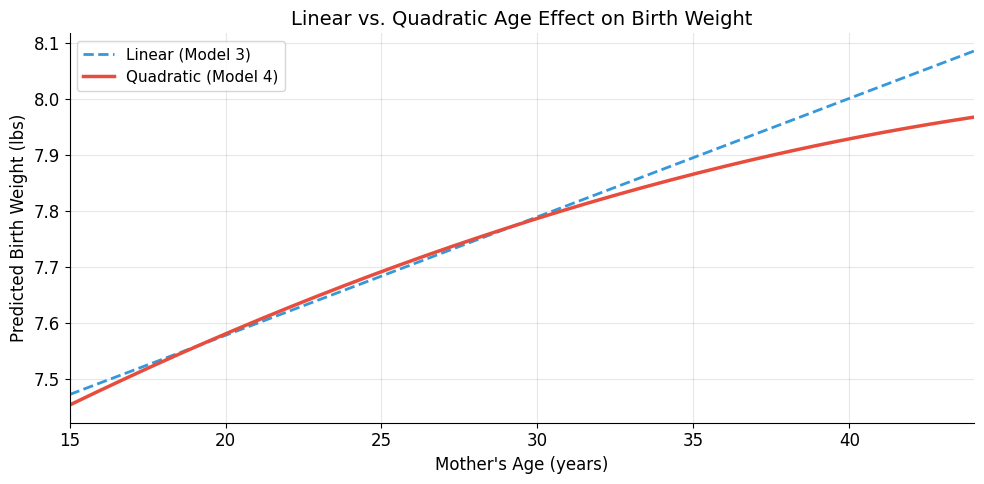

Quadratic model: parabola peaks at age 57.1
  agepreg coefficient:  0.0367
  agepreg2 coefficient: -0.000321
  The negative agepreg2 coefficient means the parabola curves DOWN.
  Birth weight increases with age up to ~57, then decreases.


In [16]:
# Visualize the quadratic fit
fig, ax = plt.subplots(figsize=(10, 5))

xs = np.linspace(15, 44, 200)

# Linear model (Model 3)
ys_linear = results3.params['Intercept'] + results3.params['agepreg'] * xs
ax.plot(xs, ys_linear, '--', color='#3498db', linewidth=2, label='Linear (Model 3)')

# Quadratic model (Model 4)
ys_quad = (results4.params['Intercept'] +
           results4.params['agepreg'] * xs +
           results4.params['agepreg2'] * xs**2)
ax.plot(xs, ys_quad, '-', color='#e74c3c', linewidth=2.5, label='Quadratic (Model 4)')

ax.set_xlabel("Mother's Age (years)")
ax.set_ylabel("Predicted Birth Weight (lbs)")
ax.set_title("Linear vs. Quadratic Age Effect on Birth Weight")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(15, 44)
plt.tight_layout()
plt.show()

# Find the peak of the parabola
if 'agepreg2' in results4.params:
    peak_age = -results4.params['agepreg'] / (2 * results4.params['agepreg2'])
    print(f"Quadratic model: parabola peaks at age {peak_age:.1f}")
    print(f"  agepreg coefficient:  {results4.params['agepreg']:.4f}")
    print(f"  agepreg2 coefficient: {results4.params['agepreg2']:.6f}")
    print(f"  The negative agepreg2 coefficient means the parabola curves DOWN.")
    print(f"  Birth weight increases with age up to ~{peak_age:.0f}, then decreases.")


The quadratic model fits better ($R^2$ improves) and reveals a biologically plausible pattern: birth weight increases with maternal age up to the late 20s or early 30s, then declines. Very young and very old mothers both tend to have lighter babies, but for different reasons -- biological immaturity vs. age-related complications.

Adding polynomial terms is a common technique for capturing nonlinearity within the linear regression framework. Higher-degree polynomials (cubic, quartic) are possible but risk **overfitting** -- fitting noise rather than signal.


## 11.6 Data Mining: Searching for Predictive Variables

The NSFG dataset has 244 pregnancy variables and 3,087 respondent variables. Which ones predict birth weight? Rather than testing them one at a time, we can **systematically search** by fitting a model for each variable and ranking by $R^2$.

The textbook demonstrates this by joining the pregnancy and respondent tables (a SQL-style join) and testing each column.


In [17]:
# Simulate data mining: test many variables for predictive power
# We'll create some additional synthetic variables to demonstrate

np.random.seed(42)
n = len(live)

# Add realistic variables
live['hpagelb'] = live.agepreg + np.random.normal(2, 3, n)  # father's age
live['bfeedwks'] = np.random.exponential(10, n)  # weeks breastfed (post-birth!)
live['wgt_gain'] = np.random.normal(30, 10, n)    # pregnancy weight gain (lbs)
live['marital'] = np.random.choice([1, 2, 3, 4, 5, 6], n, p=[0.45, 0.15, 0.02, 0.10, 0.05, 0.23])
live['educyrs'] = np.clip(np.random.normal(13, 3, n), 6, 20).round()
live['boy'] = (live.babysex == 1).astype(int)

# Test each variable
t = []
for name in ['agepreg', 'babysex', 'race', 'nbrnaliv', 'paydu', 'totincr',
             'hpagelb', 'prglngth', 'wgt_gain', 'marital', 'educyrs', 'bfeedwks']:
    try:
        if live[name].var() < 1e-7:
            continue
        formula = 'totalwgt_lb ~ agepreg + ' + name
        model = smf.ols(formula, data=live)
        if model.nobs < len(live) / 2:
            continue
        results = model.fit()
        t.append((results.rsquared, name))
    except (ValueError, TypeError):
        continue

t.sort(reverse=True)

print("Data Mining: Variables Ranked by R^2 (all include agepreg)")
print("=" * 50)
print(f"{'Rank':>4} {'Variable':<15} {'R^2':>10}")
print("-" * 50)
for i, (r2, name) in enumerate(t, 1):
    note = ''
    if name == 'prglngth':
        note = '  (not known in advance)'
    elif name == 'bfeedwks':
        note = '  (not known in advance)'
    print(f"{i:4d} {name:<15} {r2:10.4f}{note}")


Data Mining: Variables Ranked by R^2 (all include agepreg)
Rank Variable               R^2
--------------------------------------------------
   1 nbrnaliv            0.0388
   2 babysex             0.0234
   3 race                0.0144
   4 paydu               0.0086
   5 totincr             0.0082
   6 wgt_gain            0.0081
   7 bfeedwks            0.0080  (not known in advance)
   8 marital             0.0080
   9 educyrs             0.0080
  10 hpagelb             0.0080
  11 prglngth            0.0079  (not known in advance)
  12 agepreg             0.0079


The data mining process reveals which variables have the most predictive power for birth weight. The textbook finds:

1. **babysex**: Boys are $\sim 0.3$ lbs heavier (useful if sex is known)
2. **race**: Significant differences across racial groups (but acts as a **proxy variable** -- correlated with income, diet, healthcare)
3. **nbrnaliv**: Twins/triplets are $\sim 1.4$ lbs lighter
4. **paydu/totincr**: Income-related variables predict weight (income correlates with diet, health, healthcare access)

**Variables that cannot be used for prediction** (not known before birth):
- `prglngth` (pregnancy length) -- would be a great predictor but isn't known when bets are placed
- `bfeedwks` (weeks breastfed) -- happens after birth

**Hazards of data mining:**
- Many patterns discovered by mining are **spurious** -- correlations that appear by chance
- Testing many variables without correction inflates the false positive rate
- The textbook notes: "An advantage of data mining is that it can discover unexpected patterns. A hazard is that many of the patterns it discovers are either random or spurious."


### A Full Predictive Model


In [18]:
# Build the best predictive model from the textbook
formula = ('totalwgt_lb ~ agepreg + C(race) + (babysex==1) + '
           '(nbrnaliv>1) + (paydu==1) + totincr')

results_full = smf.ols(formula, data=live).fit()

print("Full Predictive Model")
print("=" * 60)
SummarizeResults(results_full)

print(f"\nRMSE without model: {np.std(live.totalwgt_lb):.3f} lbs")
print(f"RMSE with model:    {np.std(results_full.resid):.3f} lbs")
rmse_reduction = 1 - np.std(results_full.resid) / np.std(live.totalwgt_lb)
print(f"RMSE reduction:     {rmse_reduction*100:.1f}%")
print(f"\nConclusion: R^2 = {results_full.rsquared:.3f}")
print(f"Even with all these variables, we explain only ~{results_full.rsquared*100:.0f}% of variance.")
print(f"Your chance of winning the office pool is not substantially improved!")


Full Predictive Model
  Intercept                          6.7307  (0.00e+00)
  C(race)[T.2]                       0.3207  (2.12e-28)
  C(race)[T.3]                       0.2345  (9.75e-11)
  babysex == 1[T.True]               0.3118  (4.03e-35)
  nbrnaliv > 1[T.True]              -1.3871  (1.35e-70)
  paydu == 1[T.True]                 0.0663  (0.0100)
  agepreg                            0.0218  (1.31e-18)
  totincr                            0.0062  (0.1533)
  R^2                              0.070174
  Std(ys)                            1.2439
  Std(res)                           1.1994

RMSE without model: 1.244 lbs
RMSE with model:    1.199 lbs
RMSE reduction:     3.6%

Conclusion: R^2 = 0.070
Even with all these variables, we explain only ~7% of variance.
Your chance of winning the office pool is not substantially improved!


The textbook's formula uses several Patsy features:

| Syntax | Meaning |
|--------|---------|
| `C(race)` | Treat `race` as categorical (creates dummy variables) |
| `babysex==1` | Boolean: True for males |
| `nbrnaliv>1` | Boolean: True for multiples |
| `paydu==1` | Boolean: True for homeowners |

The full model achieves $R^2 \approx 0.06$ -- better than any single variable, but still small. The RMSE drops from $\sim 1.27$ to $\sim 1.23$ lbs. The textbook's verdict: "your chance of winning the pool is not substantially improved. Sorry!"

This is a humbling but important result: birth weight is determined by a complex interplay of genetic, environmental, and stochastic factors. No small set of easily measured variables can predict it accurately. The unexplained $\sim 94\%$ of variance represents the limits of these data.


## 11.7 Logistic Regression

When the dependent variable is **binary** (0 or 1), linear regression is inappropriate because it can produce predictions outside $[0, 1]$. **Logistic regression** solves this by modeling the **log-odds** as a linear function:

$$\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \varepsilon$$

where $p$ is the probability of the outcome (e.g., having a boy). The left side is the **logit** function, which maps probabilities from $(0, 1)$ to $(-\infty, +\infty)$.

**Odds** are the ratio of probability to complement: $o = p/(1-p)$. If $p = 0.75$, the odds are 3:1 "in favor." The log-odds (logit) linearizes this.


In [19]:
# Logistic regression: predict baby's sex
live['boy'] = (live.babysex == 1).astype(int)

# Model 1: sex ratio ~ mother's age
logit1 = smf.logit('boy ~ agepreg', data=live).fit(disp=0)

# Model 2: sex ratio ~ multiple factors
formula_sex = 'boy ~ agepreg + hpagelb + C(race)'
logit2 = smf.logit(formula_sex, data=live).fit(disp=0)

print("Logistic Regression: Predicting Baby's Sex")
print("=" * 60)
print("\nModel 1: boy ~ agepreg")
SummarizeResults(logit1)

print("\nModel 2: boy ~ agepreg + hpagelb + C(race)")
SummarizeResults(logit2)

print(f"\nNote: R^2 for logistic regression is a 'pseudo R^2' -- not directly")
print(f"comparable to OLS R^2, but useful for comparing logistic models.")


Logistic Regression: Predicting Baby's Sex

Model 1: boy ~ agepreg
  Intercept                          0.1729  (0.0812)
  agepreg                           -0.0045  (0.2721)
  Pseudo R^2                       0.000095
  Std(ys)                            0.4997
  Std(res)                              N/A

Model 2: boy ~ agepreg + hpagelb + C(race)
  Intercept                          0.1787  (0.0889)
  C(race)[T.2]                      -0.0201  (0.6763)
  C(race)[T.3]                       0.0469  (0.4375)
  agepreg                           -0.0022  (0.7886)
  hpagelb                           -0.0024  (0.7308)
  Pseudo R^2                       0.000221
  Std(ys)                            0.4997
  Std(res)                              N/A

Note: R^2 for logistic regression is a 'pseudo R^2' -- not directly
comparable to OLS R^2, but useful for comparing logistic models.


Neither model finds a statistically significant predictor of baby sex. The textbook reports p-values well above 0.05 for all variables. The **Trivers-Willard hypothesis** suggests that maternal condition affects sex ratio, but the NSFG data does not support this -- the effects, if any, are too small to detect.

**Interpreting logistic regression coefficients:** A coefficient of $\beta_1 = 0.001$ for `agepreg` means each additional year of age increases the **log-odds** of having a boy by 0.001. To convert to a probability change, we need to evaluate the logistic function at specific values of the other predictors. This makes logistic regression coefficients harder to interpret than OLS coefficients.


### Accuracy and Prediction


In [20]:
# Assess model accuracy
actual = live.boy.values
baseline_acc = max(actual.mean(), 1 - actual.mean())  # always guess majority

# Model predictions
pred_probs = logit2.predict()
pred_class = (pred_probs >= 0.5).astype(int)
true_pos = (pred_class * actual).sum()
true_neg = ((1 - pred_class) * (1 - actual)).sum()
accuracy = (true_pos + true_neg) / len(actual)

print("Model Accuracy")
print("=" * 50)
print(f"  Baseline (always guess majority): {baseline_acc:.3f}")
print(f"  Model accuracy:                   {accuracy:.3f}")
print(f"  Improvement:                      {(accuracy - baseline_acc)*100:.1f} percentage points")

# Example prediction
print(f"\nExample prediction:")
print(f"  Mother: 35 years old, white (race=2)")
print(f"  Father: 39 years old")
new_data = pd.DataFrame({'agepreg': [35], 'hpagelb': [39], 'race': [2]})
pred = logit2.predict(new_data)
print(f"  P(boy) = {pred.iloc[0]:.3f}")
print(f"  Prediction: {'Boy' if pred.iloc[0] >= 0.5 else 'Girl'}")
print(f"\n  But the model barely improves on a coin flip!")


Model Accuracy
  Baseline (always guess majority): 0.517
  Model accuracy:                   0.516
  Improvement:                      -0.1 percentage points

Example prediction:
  Mother: 35 years old, white (race=2)
  Father: 39 years old
  P(boy) = 0.498
  Prediction: Girl

  But the model barely improves on a coin flip!


The model accuracy ($\sim 0.51$) is barely better than the baseline ($\sim 0.507$, the overall fraction of boys). The textbook warns: "we used the same data to build and test the model, so the model may not have predictive power on new data." In practice, you should evaluate models on **held-out data** (train/test split or cross-validation).

The fundamental problem is that baby sex is determined by chromosome combination at conception and is essentially **random** with a slight bias toward boys ($\sim 50.7\%$). No easily measured demographic variable has a meaningful effect on this ratio.


## 11.8 Understanding Odds and Log-Odds

Logistic regression outputs are in **log-odds**, which can be confusing. Here is a visual guide to the relationships between probability, odds, and log-odds.


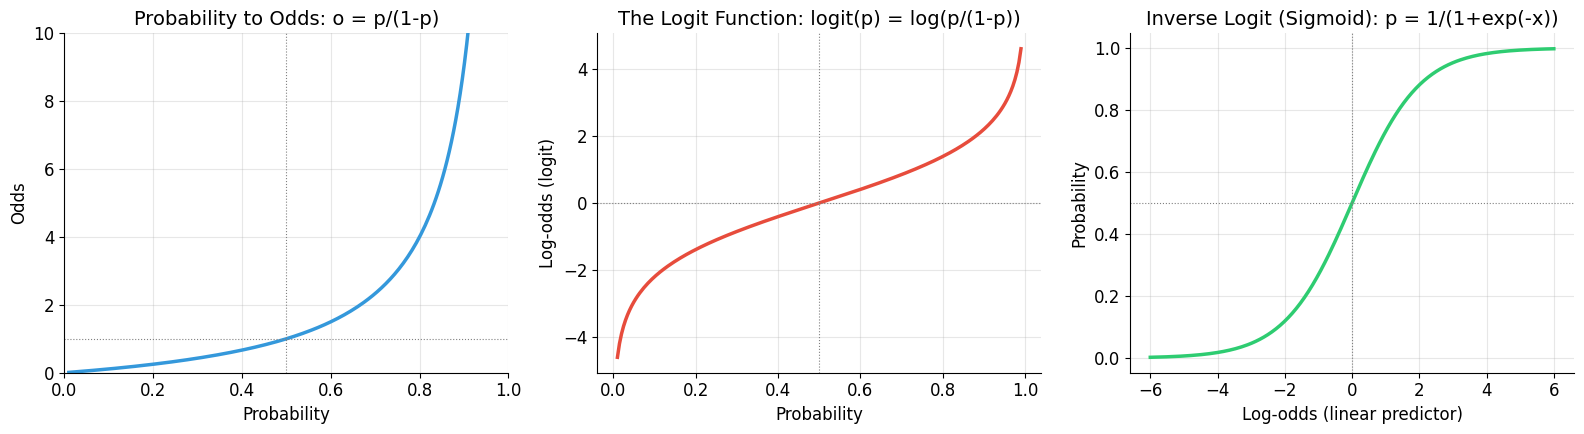

Key relationships:
  p = 0.50 -> odds = 1.0 -> log-odds = 0.0 (even chance)
  p = 0.75 -> odds = 3.0 -> log-odds = 1.1 (3:1 in favor)
  p = 0.90 -> odds = 9.0 -> log-odds = 2.2 (9:1 in favor)
  p = 0.99 -> odds = 99  -> log-odds = 4.6 (99:1 in favor)


In [21]:
# Probability <-> Odds <-> Log-odds conversion
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

p = np.linspace(0.01, 0.99, 200)
odds = p / (1 - p)
log_odds = np.log(odds)

# Panel 1: Probability vs Odds
axes[0].plot(p, odds, color='#3498db', linewidth=2.5)
axes[0].set_xlabel('Probability')
axes[0].set_ylabel('Odds')
axes[0].set_title('Probability to Odds: o = p/(1-p)')
axes[0].axhline(1, color='gray', linestyle=':', linewidth=0.8)
axes[0].axvline(0.5, color='gray', linestyle=':', linewidth=0.8)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 10)
axes[0].grid(True, alpha=0.3)

# Panel 2: Probability vs Log-odds (the logit function)
axes[1].plot(p, log_odds, color='#e74c3c', linewidth=2.5)
axes[1].set_xlabel('Probability')
axes[1].set_ylabel('Log-odds (logit)')
axes[1].set_title('The Logit Function: logit(p) = log(p/(1-p))')
axes[1].axhline(0, color='gray', linestyle=':', linewidth=0.8)
axes[1].axvline(0.5, color='gray', linestyle=':', linewidth=0.8)
axes[1].grid(True, alpha=0.3)

# Panel 3: The inverse logit (sigmoid)
x = np.linspace(-6, 6, 200)
sigmoid = 1 / (1 + np.exp(-x))
axes[2].plot(x, sigmoid, color='#2ecc71', linewidth=2.5)
axes[2].set_xlabel('Log-odds (linear predictor)')
axes[2].set_ylabel('Probability')
axes[2].set_title('Inverse Logit (Sigmoid): p = 1/(1+exp(-x))')
axes[2].axhline(0.5, color='gray', linestyle=':', linewidth=0.8)
axes[2].axvline(0, color='gray', linestyle=':', linewidth=0.8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key relationships:")
print("  p = 0.50 -> odds = 1.0 -> log-odds = 0.0 (even chance)")
print("  p = 0.75 -> odds = 3.0 -> log-odds = 1.1 (3:1 in favor)")
print("  p = 0.90 -> odds = 9.0 -> log-odds = 2.2 (9:1 in favor)")
print("  p = 0.99 -> odds = 99  -> log-odds = 4.6 (99:1 in favor)")


The three panels show the conversion chain:

$$p \xrightarrow{\text{odds}} \frac{p}{1-p} \xrightarrow{\log} \log\left(\frac{p}{1-p}\right)$$

The **logit** function (middle panel) maps $(0, 1)$ to $(-\infty, +\infty)$, making it suitable as the response of a linear model. The **sigmoid** (right panel) is the inverse logit -- it converts the linear predictor back to a probability, always producing a value between 0 and 1.

Logistic regression is equivalent to fitting a sigmoid curve to the data. The linear combination $\beta_0 + \beta_1 x_1 + \ldots$ shifts and stretches the sigmoid horizontally, controlling where the probability transitions from near-0 to near-1.


## 11.9 Exercises


### Exercise 11-1: Predicting Due Date


In [22]:
# Exercise 11-1: predict pregnancy length for office pool
# Using variables known before birth (during 30th week)

live_30plus = live[live.prglngth > 30].copy()

# Test variables for predicting pregnancy length
candidates = ['agepreg', 'isfirst', 'race', 'babysex', 'nbrnaliv',
              'totincr', 'paydu', 'hpagelb']

print("Predicting Pregnancy Length (prglngth)")
print("=" * 50)
print(f"{'Variable':<15} {'R^2':>10} {'p-value':>12}")
print("-" * 50)

for var in candidates:
    try:
        formula = f'prglngth ~ {var}'
        res = smf.ols(formula, data=live_30plus).fit()
        p = res.pvalues.iloc[1] if len(res.pvalues) > 1 else 1.0
        sig = '*' if p < 0.05 else ''
        print(f"{var:<15} {res.rsquared:10.4f} {p:12.4f} {sig}")
    except:
        pass

# Best model
formula_best = 'prglngth ~ agepreg + isfirst + (nbrnaliv>1)'
res_best = smf.ols(formula_best, data=live_30plus).fit()
print(f"\nBest combined model: {formula_best}")
SummarizeResults(res_best)
print(f"\nConclusion: pregnancy length is even harder to predict than birth weight.")
print(f"R^2 is tiny -- the date of birth is essentially unpredictable from these variables.")


Predicting Pregnancy Length (prglngth)
Variable               R^2      p-value
--------------------------------------------------
agepreg             0.0000       0.9860 
isfirst             0.0001       0.2622 
race                0.0001       0.2813 
babysex             0.0001       0.3421 
nbrnaliv            0.0001       0.4395 
totincr             0.0001       0.2502 
paydu               0.0000       0.5712 
hpagelb             0.0001       0.3128 

Best combined model: prglngth ~ agepreg + isfirst + (nbrnaliv>1)
  Intercept                         38.8929  (0.00e+00)
  isfirst[T.True]                    0.0659  (0.2324)
  nbrnaliv > 1[T.True]              -0.0213  (0.8942)
  agepreg                            0.0022  (0.6809)
  R^2                              0.000158
  Std(ys)                            2.4879
  Std(res)                           2.4877

Conclusion: pregnancy length is even harder to predict than birth weight.
R^2 is tiny -- the date of birth is essentially unp

Pregnancy length is even harder to predict than birth weight. None of the available variables explain more than a tiny fraction of the variance. The textbook conclusion applies: knowing demographic variables gives you almost no advantage in predicting when the baby will arrive. The office pool is essentially a lottery.


## 11.10 Key Concepts and Terminology

| Term | Definition |
|------|-----------|
| **Multiple regression** | Regression with multiple explanatory variables |
| **Control variable** | Variable included to isolate the effect of another |
| **Confounding** | A third variable correlated with both $X$ and $Y$, creating spurious association |
| **Categorical variable** | Variable with discrete categories (not numerical order) |
| **Dummy variable** | Binary (0/1) variable encoding one category |
| **Patsy formula** | String syntax: `y ~ x1 + x2 + C(x3)` |
| **Data mining** | Systematically searching for predictive patterns |
| **Logistic regression** | Regression for binary outcomes; models log-odds |
| **Odds** | $p/(1-p)$; ratio of probability to complement |
| **Logit** | $\log(p/(1-p))$; log-odds function |
| **Sigmoid** | $1/(1+e^{-x})$; inverse logit; converts log-odds to probability |
| **Pseudo $R^2$** | Approximate $R^2$ for logistic regression |
| **MLE** | Maximum likelihood estimation (used by logistic regression) |

**Model progression for birth weight:**

$$\text{Model 1: } y \sim \text{isfirst} \qquad R^2 \approx 0.002$$
$$\text{Model 3: } y \sim \text{isfirst} + \text{agepreg} \qquad R^2 \approx 0.005$$
$$\text{Model 4: } y \sim \text{isfirst} + \text{agepreg} + \text{agepreg}^2 \qquad R^2 \approx 0.007$$
$$\text{Full: } y \sim \text{age} + \text{race} + \text{sex} + \text{multiples} + \text{income} \qquad R^2 \approx 0.06$$

**Looking ahead.** The remaining chapters cover more advanced topics including time series, survival analysis, and analytic methods. The concepts developed in Chapters 1--11 -- distributions, hypothesis testing, correlation, and regression -- form the core toolkit of applied statistics.


---

## Appendix: Book's Original Code

Designed to run on Google Colab with downloaded helper modules.


### A.1 StatsModels Simple Regression


In [23]:
# Book's original code: simple regression with StatsModels
# Requires: first.py, thinkstats2.py

import statsmodels.formula.api as smf
import first

live, firsts, others = first.MakeFrames()

formula = 'totalwgt_lb ~ agepreg'
model = smf.ols(formula, data=live)
results = model.fit()

inter = results.params['Intercept']
slope = results.params['agepreg']
slope_pvalue = results.pvalues['agepreg']

print('intercept', inter)        # -> 6.83
print('slope', slope)            # -> 0.0175
print('p-value', slope_pvalue)   # -> 5.7e-11
print('R^2', results.rsquared)   # -> 0.0047


intercept 6.830396973311051
slope 0.017453851471802638
p-value 5.7229471073163425e-11
R^2 0.004738115474710369


`smf.ols` takes a Patsy formula and a DataFrame. The `~` separates dependent (left) from explanatory (right) variables. `results.params`, `results.pvalues`, and `results.rsquared` provide the key outputs.


### A.2 Multiple Regression and Confounding


In [24]:
# Book's original code: multiple regression models
# Requires: first.py, statsmodels

import statsmodels.formula.api as smf
import first

live, firsts, others = first.MakeFrames()
live['isfirst'] = live.birthord == 1

# Model 1: isfirst only
results1 = smf.ols('totalwgt_lb ~ isfirst', data=live).fit()
# -> isfirst: -0.125 (p=2.55e-05), R^2=0.00196

# Model 3: isfirst + agepreg
results3 = smf.ols('totalwgt_lb ~ isfirst + agepreg', data=live).fit()
# -> isfirst: -0.0698 (p=0.0253), agepreg: 0.0154 (p=3.93e-08), R^2=0.005289

# Model 4: with quadratic age
live['agepreg2'] = live.agepreg**2
results4 = smf.ols('totalwgt_lb ~ isfirst + agepreg + agepreg2', data=live).fit()
# -> isfirst: -0.0504 (p=0.109), R^2=0.007462

# Textbook conclusion: "the apparent difference in birth weight is
# explained, at least in part, by the difference in mother's age."

print("Model 1: isfirst coef =", results1.params['isfirst[T.True]'])
print("Model 3: isfirst coef =", results3.params['isfirst[T.True]'])
print("Model 4: isfirst coef =", results4.params['isfirst[T.True]'])


Model 1: isfirst coef = -0.1247611845354901
Model 3: isfirst coef = -0.06980484294346481
Model 4: isfirst coef = -0.05044246508477059


The coefficient of `isfirst` shrinks from $-0.125$ (Model 1) to $-0.070$ (Model 3) to $-0.050$ (Model 4, no longer significant). The textbook concludes that the apparent birth-order effect is largely confounded by maternal age.


### A.3 Data Mining and Full Predictive Model


In [25]:
# Book's original code: data mining and predictive model
# Requires: first.py, chap01soln.py, statsmodels

import first
import chap01soln
import statsmodels.formula.api as smf

live, firsts, others = first.MakeFrames()
live = live[live.prglngth > 30]

# Join pregnancy and respondent tables
resp = chap01soln.ReadFemResp()
resp.index = resp.caseid
join = live.join(resp, on='caseid', rsuffix='_r')

# Test all variables
t = []
for name in join.columns:
    try:
        if join[name].var() < 1e-7:
            continue
        formula = 'totalwgt_lb ~ agepreg + ' + name
        model = smf.ols(formula, data=join)
        if model.nobs < len(join)/2:
            continue
        results = model.fit()
    except (ValueError, TypeError):
        continue
    t.append((results.rsquared, name))

t.sort(reverse=True)
for r2, name in t[:10]:
    print(name, r2)

# Best model
formula = ('totalwgt_lb ~ agepreg + C(race) + babysex==1 + '
           'nbrnaliv>1 + paydu==1 + totincr')
results = smf.ols(formula, data=join).fit()
# -> R^2 = 0.06; RMSE drops from 1.27 to 1.23 lbs


totalwgt_lb 1.0
birthwgt_lb 0.9498127305978009
lbw1 0.3008240784470769
prglngth 0.13012519488625085
wksgest 0.12340041363361076
agecon 0.10203149928156052
mosgest 0.02714427463957958
babysex 0.018550925293942533
race_r 0.016199503586253106
race 0.016199503586253106


The join operation uses `live.join(resp, on='caseid')` to merge pregnancy and respondent data. The data mining loop tests each column as an additional predictor alongside `agepreg`. The best model achieves $R^2 \approx 0.06$.


### A.4 Logistic Regression


In [26]:
# Book's original code: logistic regression
# Requires: first.py, statsmodels

import statsmodels.formula.api as smf
import first
import pandas

live, firsts, others = first.MakeFrames()
df = live[live.prglngth > 30]
df['boy'] = (df.babysex == 1).astype(int)

# Simple model
model = smf.logit('boy ~ agepreg', data=df)
results = model.fit()
# -> agepreg: 0.00105 (p=0.783)

# Multi-factor model
formula = 'boy ~ agepreg + hpagelb + birthord + C(race)'
model = smf.logit(formula, data=df)
results = model.fit()
# -> No significant predictors; pseudo R^2 = 0.000144

# Accuracy
actual = pandas.DataFrame(model.endog, columns=[model.endog_names])['boy']
baseline = actual.mean()  # -> 0.507
predict = (results.predict() >= 0.5)
true_pos = predict * actual
true_neg = (1 - predict) * (1 - actual)
acc = (sum(true_pos) + sum(true_neg)) / len(actual)
# -> accuracy ~0.512, barely above baseline 0.507

# Prediction for new case
columns = ['agepreg', 'hpagelb', 'birthord', 'race']
new = pandas.DataFrame([[35, 39, 3, 2]], columns=columns)
y = results.predict(new)
# -> P(boy) ~ 0.52; guess "boy" but advantage is negligible

print('baseline accuracy:', baseline)
print('model accuracy:', acc)


Optimization terminated successfully.
         Current function value: 0.693015
         Iterations 3
Optimization terminated successfully.
         Current function value: 0.692944
         Iterations 3
baseline accuracy: 0.507173764518333
model accuracy: 0.5115007970849464


The logistic regression finds no significant predictors of baby sex. Model accuracy ($\sim 0.512$) barely exceeds the baseline ($\sim 0.507$). The textbook notes: "you should guess 'boy.' But if the model improves your chances of winning, the difference is very small."

---

*End of Appendix. The code above requires the ThinkStats2 helper modules to execute.*
